# 🚗 Predictive Ride Matching — Data Visualization

Notebook này visualize dữ liệu synthetic ride-hailing được tạo từ `scripts/generate_synthetic_data.py`.

**Các phần:**
1. Load & Tổng quan dữ liệu
2. Phân phối các feature số
3. Phân tích theo giờ & giờ cao điểm
4. Phân tích Travel Mode
5. Phân tích ETA & EDA
6. Phân tích Giá (total_fee / total_pay)
7. Tỉ lệ hoàn thành (is_completed)
8. Correlation Heatmap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Cấu hình style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLOR_PRIMARY   = '#4C72B0'
COLOR_ACCENT    = '#DD8452'
COLOR_SUCCESS   = '#55A868'
COLOR_DANGER    = '#C44E52'
PALETTE_MODE    = ['#4C72B0', '#DD8452', '#55A868']

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load & Tổng quan dữ liệu

In [2]:
DATA_PATH = Path('../data/raw/synthetic_ride_data.csv')

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 1,500,000 rows × 29 columns


,order_id,matching_batch_id,driver_id,num_drivers,num_orders,eta_avg,eta_std,eta_min,eta_inv1,eta_inv10,...,rush_hour,travel_mode,user_waiting_time_seconds,distance,total_fee,total_pay,est_time_arrival,est_distance_arrival,estimate_dropoff_time,is_completed
0,order_1,batch_121959,driver_399930,140,3,807.959420,136.907468,764.915896,0.001236,0.001223,...,0,3,826.902439,12.096457,168000.0,145000.0,905.665168,12.021956,1.781362e+09,1
1,order_2,batch_671156,driver_312188,142,40,1064.586370,211.896063,1024.189600,0.000938,0.000931,...,1,1,85.134649,10.935838,81000.0,57000.0,1013.832848,10.565770,1.781470e+09,1
2,order_3,batch_131933,driver_110079,26,98,754.775347,92.701727,736.883826,0.001323,0.001308,...,0,1,144.381340,7.363815,41000.0,32000.0,801.704562,7.928561,1.781258e+09,1
3,order_4,batch_259179,driver_58460,89,26,1341.808506,288.635600,1329.009008,0.000745,0.000740,...,0,3,512.859216,11.095743,157000.0,156000.0,1295.181524,10.666016,1.781752e+09,1
4,order_5,batch_110269,driver_264519,20,13,548.350394,122.963305,517.147569,0.001820,0.001791,...,0,3,52.714953,8.841737,132000.0,113000.0,584.429673,9.206705,1.781041e+09,1


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
order_id                      object
matching_batch_id             object
driver_id                     object
num_drivers                    int64
num_orders                     int64
eta_avg                      float64
eta_std                      float64
eta_min                      float64
eta_inv1                     float64
eta_inv10                    float64
eta_inv100                   float64
eda_avg                      float64
eda_std                      float64
eda_min                      float64
eda_inv1                     float64
eda_inv10                    float64
eda_inv100                   float64
hour_of_day                    int64
minute_of_hour                 int64
rush_hour                      int64
travel_mode                    int64
user_waiting_time_seconds    float64
distance                     float64
total_fee                    float64
total_pay                    float64
est_time_arrival             float64
est_distance_arriva

In [4]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'min', 'max'])

,count,mean,std,min,25%,50%,75%,max
num_drivers,1500000.000000,75.056511,43.021188,1.000000,38.000000,75.000000,112.000000,149.000000
num_orders,1500000.000000,49.977883,28.591197,1.000000,25.000000,50.000000,75.000000,99.000000
eta_avg,1500000.000000,929.886899,502.274697,60.000925,494.663886,930.501426,1364.298269,1799.999855
eta_std,1500000.000000,152.442393,85.176707,5.000099,78.714660,152.381364,226.275598,299.999779
eta_min,1500000.000000,894.870166,502.503412,10.000000,459.678912,895.378130,1329.536888,1789.675295
eta_inv1,1500000.000000,0.001947,0.002308,0.000555,0.000732,0.001074,0.002017,0.016393
eta_inv10,1500000.000000,0.001870,0.002099,0.000552,0.000728,0.001063,0.001982,0.014286
eta_inv100,1500000.000000,0.001423,0.001126,0.000526,0.000683,0.000970,0.001682,0.006250
eda_avg,1500000.000000,7.745787,4.183549,0.500007,4.124018,7.747316,11.365431,14.999991
eda_std,1500000.000000,1.050413,0.548350,0.100001,0.575240,1.050827,1.525489,1.999999


## 2. Phân phối các feature số

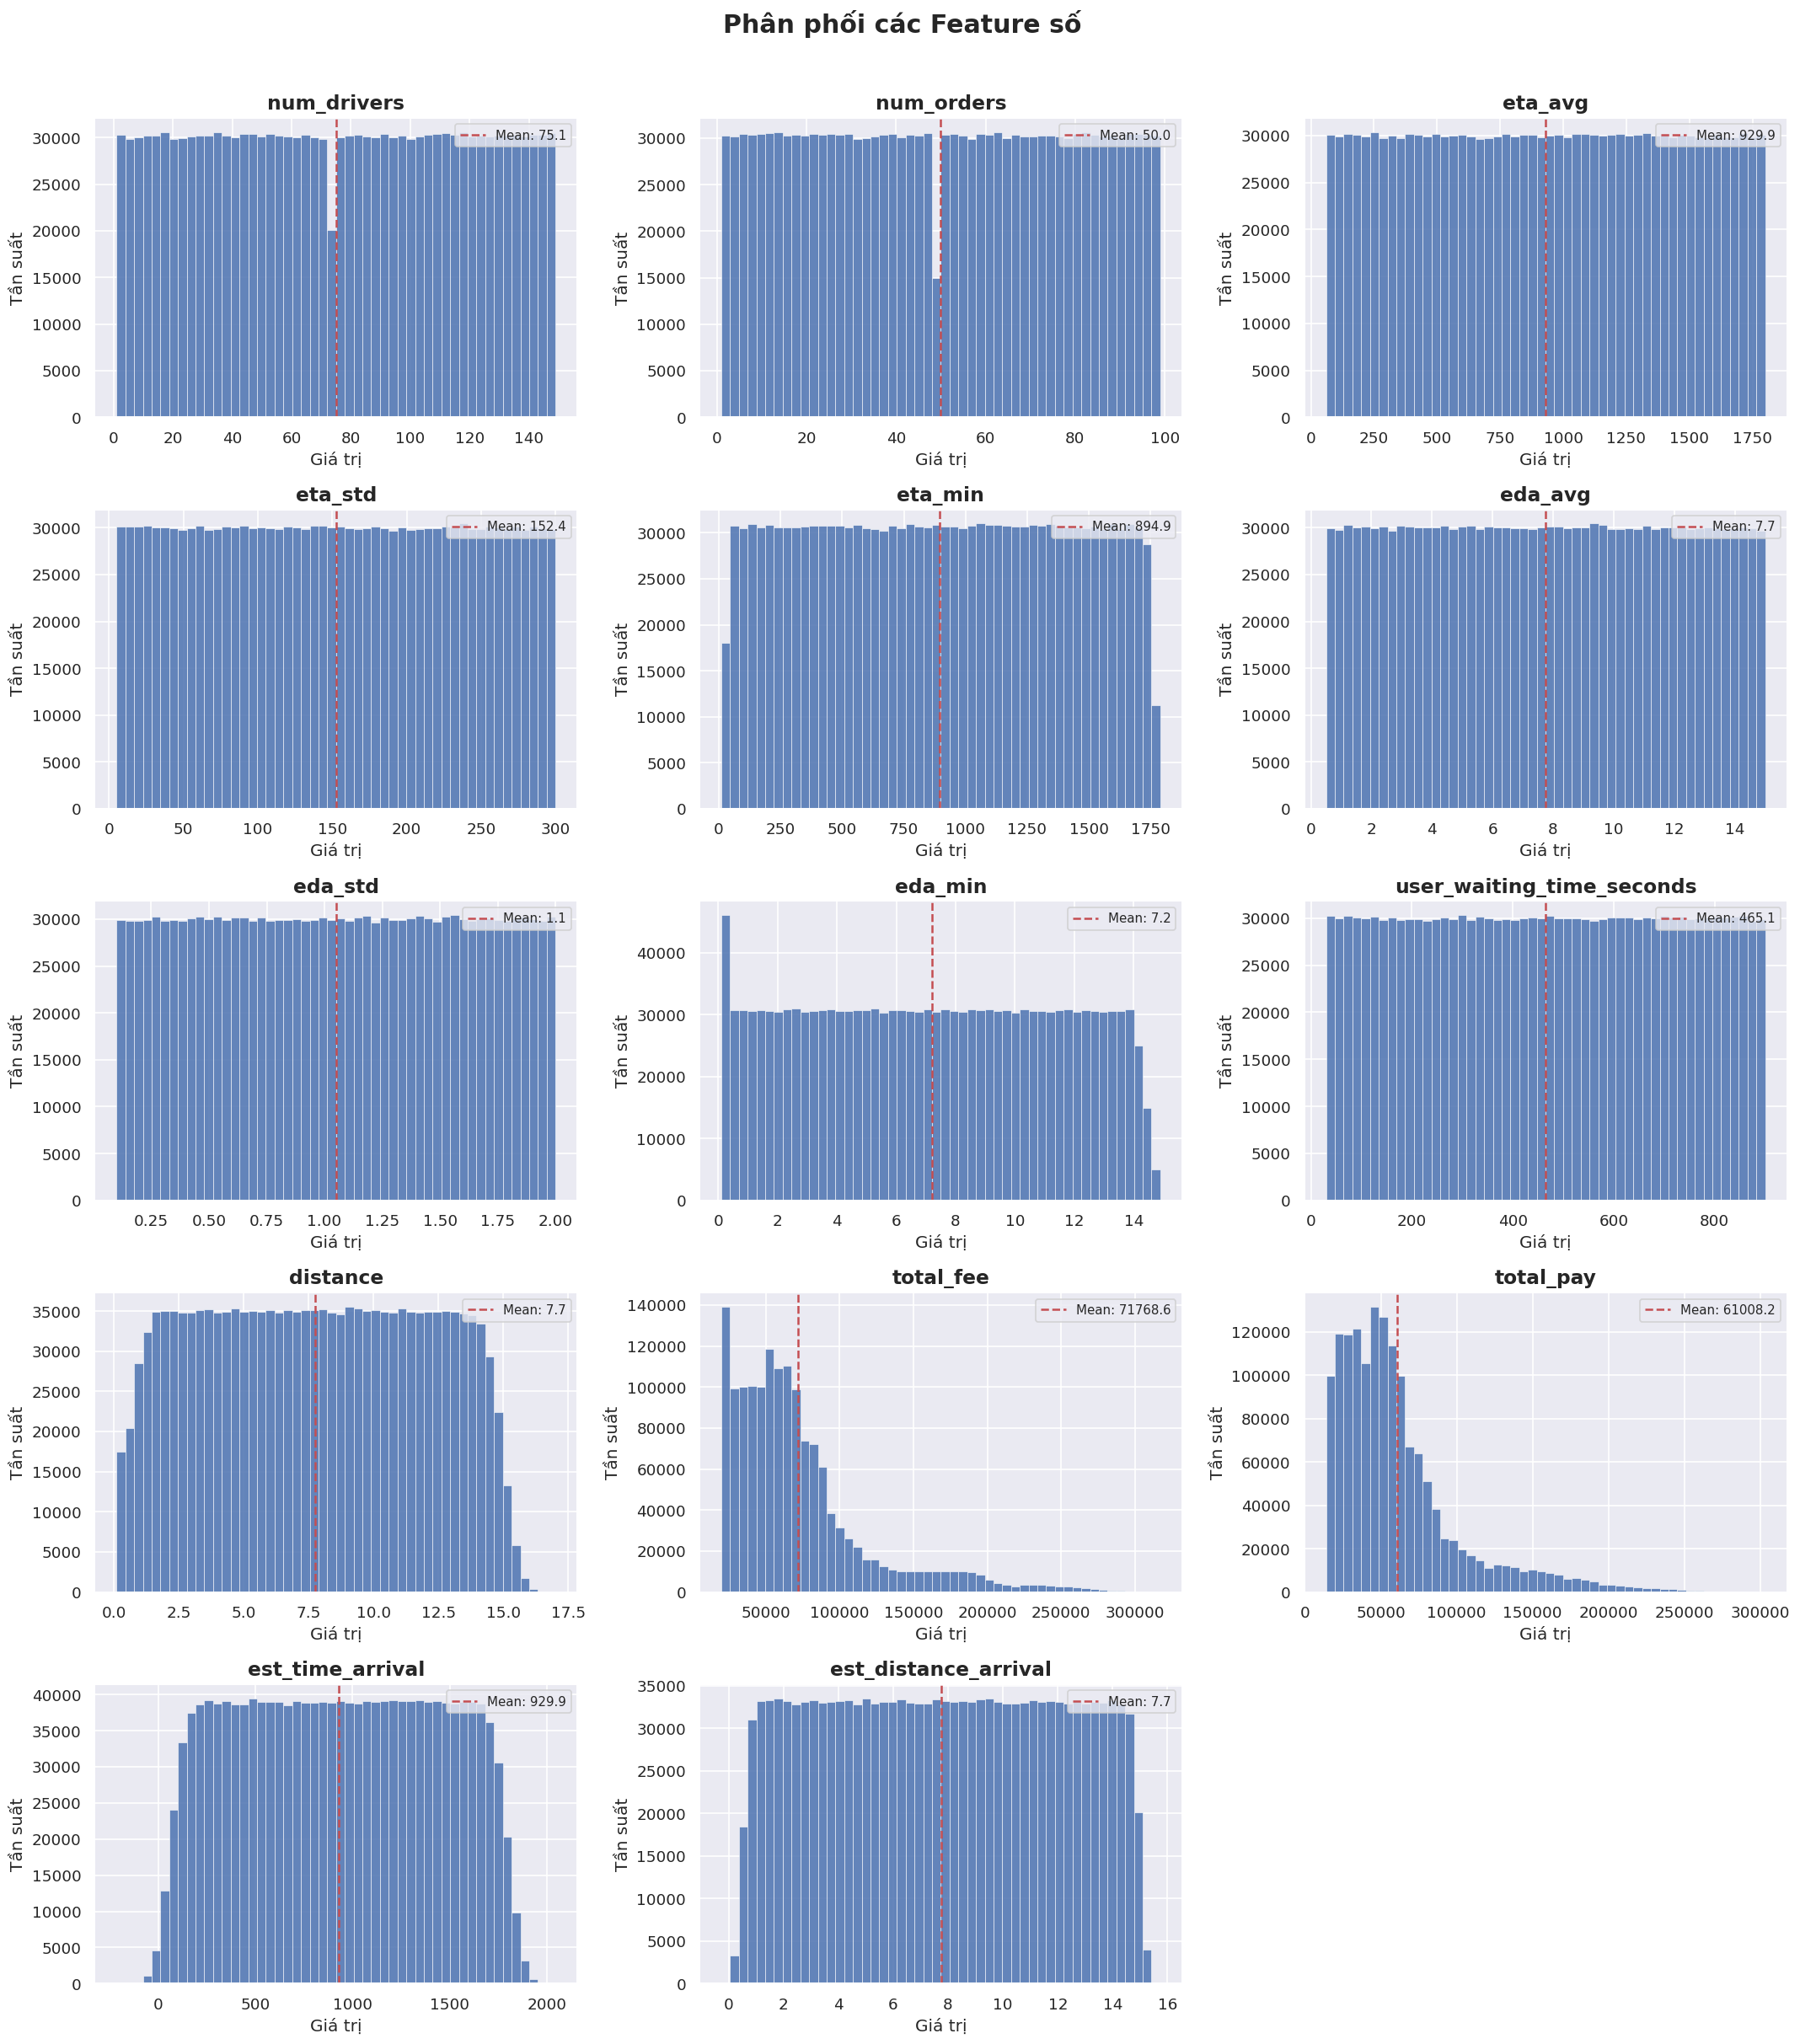

In [5]:
numeric_cols = [
    'num_drivers', 'num_orders',
    'eta_avg', 'eta_std', 'eta_min',
    'eda_avg', 'eda_std', 'eda_min',
    'user_waiting_time_seconds', 'distance',
    'total_fee', 'total_pay',
    'est_time_arrival', 'est_distance_arrival',
]

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=50, color=COLOR_PRIMARY, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Giá trị')
    ax.set_ylabel('Tần suất')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color=COLOR_DANGER, linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=9)

# Tắt axes thừa
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Phân phối các Feature số', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Phân tích theo giờ & giờ cao điểm

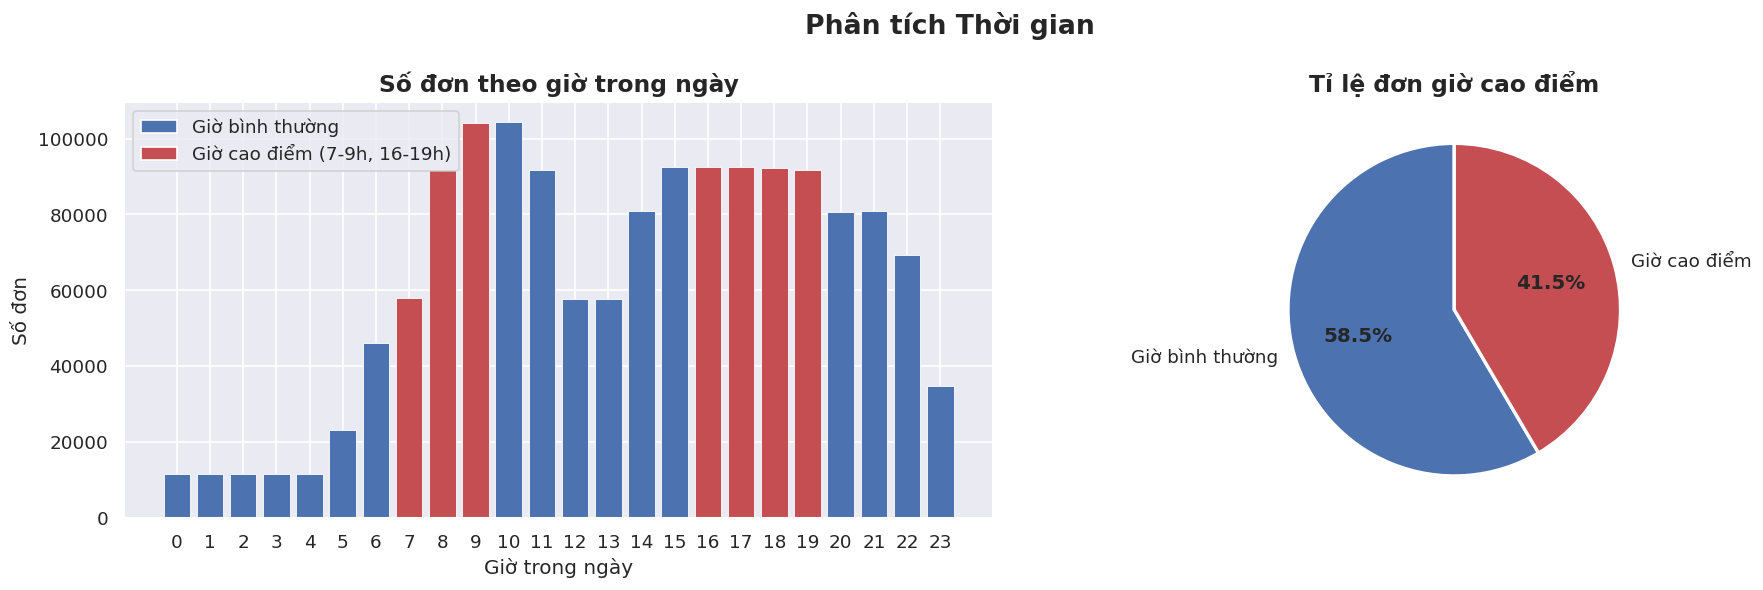

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3a. Số đơn theo giờ trong ngày
ax = axes[0]
hourly_counts = df.groupby('hour_of_day').size()
colors = ['#C44E52' if h in list(range(7,10)) + list(range(16,20)) else COLOR_PRIMARY
          for h in hourly_counts.index]
ax.bar(hourly_counts.index, hourly_counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Số đơn theo giờ trong ngày', fontweight='bold')
ax.set_xlabel('Giờ trong ngày')
ax.set_ylabel('Số đơn')
ax.set_xticks(range(24))
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLOR_PRIMARY, label='Giờ bình thường'),
                   Patch(facecolor=COLOR_DANGER, label='Giờ cao điểm (7-9h, 16-19h)')]
ax.legend(handles=legend_elements)

# 3b. Tỉ lệ đơn giờ cao điểm vs bình thường
ax2 = axes[1]
rush_counts = df['rush_hour'].value_counts().sort_index()
labels = ['Giờ bình thường', 'Giờ cao điểm']
wedge_colors = [COLOR_PRIMARY, COLOR_DANGER]
wedges, texts, autotexts = ax2.pie(
    rush_counts.values,
    labels=labels,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax2.set_title('Tỉ lệ đơn giờ cao điểm', fontweight='bold')

plt.suptitle('Phân tích Thời gian', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

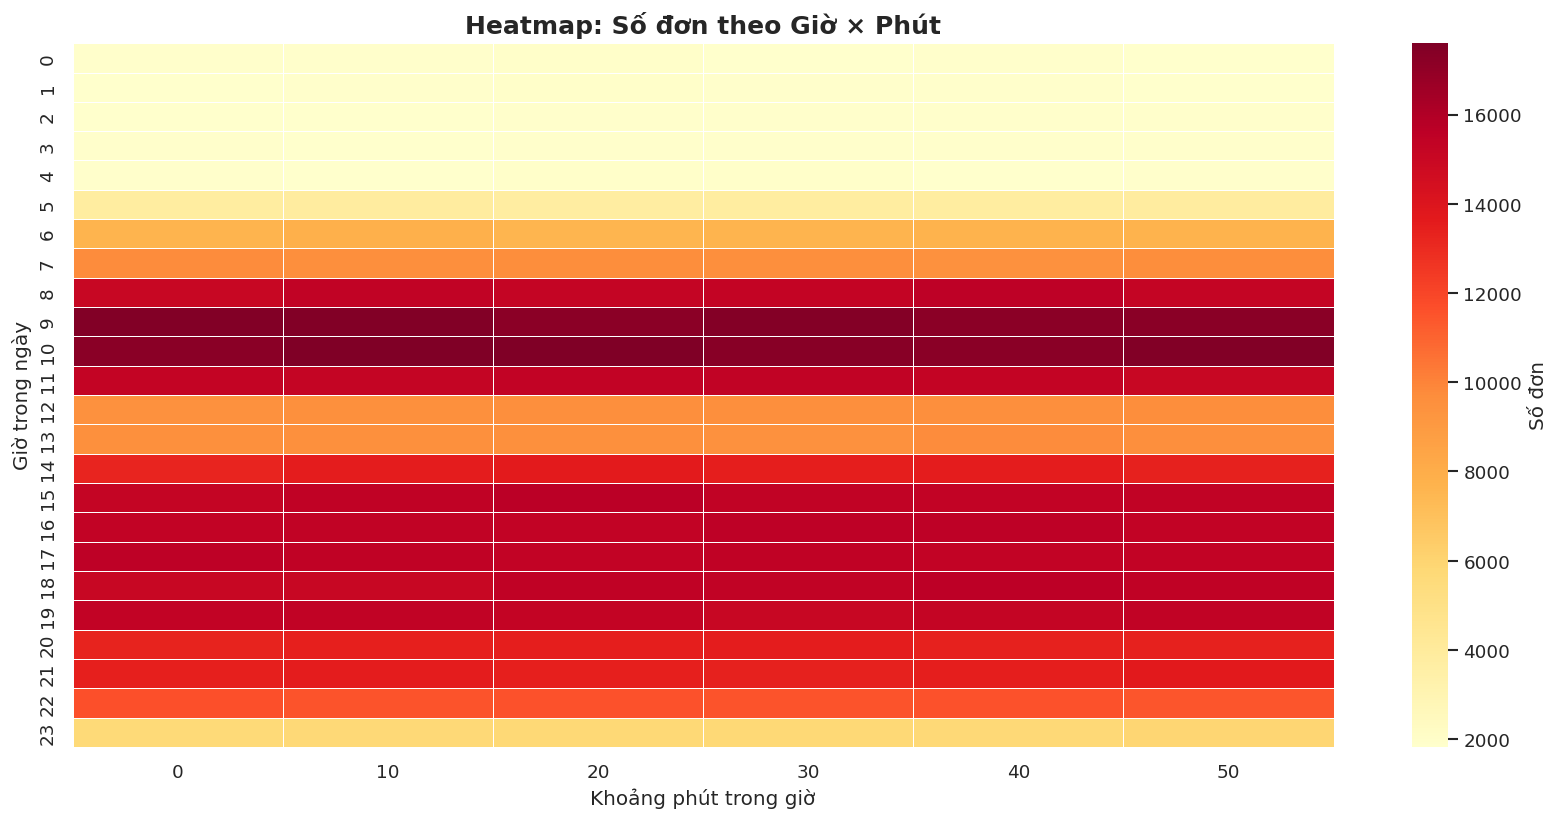

In [7]:
# Heatmap: số đơn theo giờ × phút (mỗi 10 phút)
df['minute_bin'] = (df['minute_of_hour'] // 10) * 10
heatmap_data = df.groupby(['hour_of_day', 'minute_bin']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Số đơn'}
)
ax.set_title('Heatmap: Số đơn theo Giờ × Phút', fontsize=15, fontweight='bold')
ax.set_xlabel('Khoảng phút trong giờ')
ax.set_ylabel('Giờ trong ngày')
plt.tight_layout()
plt.show()

## 4. Phân tích Travel Mode

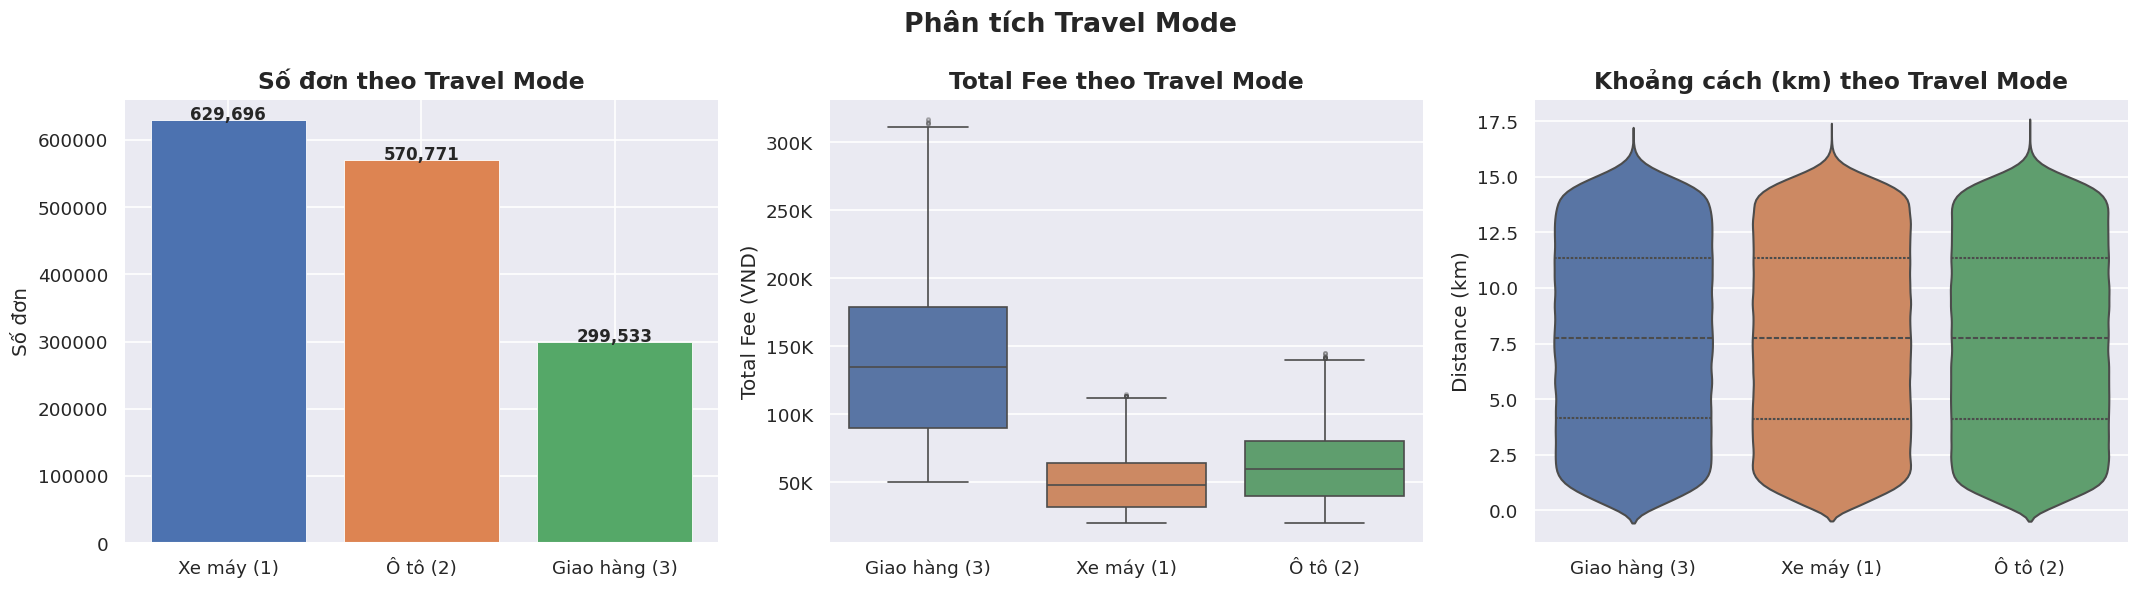

In [8]:
mode_labels = {1: 'Xe máy (1)', 2: 'Ô tô (2)', 3: 'Giao hàng (3)'}
df['travel_mode_label'] = df['travel_mode'].map(mode_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4a. Phân phối travel mode
ax = axes[0]
mode_counts = df['travel_mode_label'].value_counts()
ax.bar(mode_counts.index, mode_counts.values, color=PALETTE_MODE, edgecolor='white', linewidth=0.5)
ax.set_title('Số đơn theo Travel Mode', fontweight='bold')
ax.set_ylabel('Số đơn')
for i, (v, c) in enumerate(zip(mode_counts.index, mode_counts.values)):
    ax.text(i, c + 30, f'{c:,}', ha='center', fontsize=10, fontweight='bold')

# 4b. Total fee theo travel mode
ax2 = axes[1]
sns.boxplot(
    data=df, x='travel_mode_label', y='total_fee',
    palette=PALETTE_MODE, ax=ax2,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
ax2.set_title('Total Fee theo Travel Mode', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Total Fee (VND)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 4c. Distance theo travel mode
ax3 = axes[2]
sns.violinplot(
    data=df, x='travel_mode_label', y='distance',
    palette=PALETTE_MODE, ax=ax3, inner='quartile'
)
ax3.set_title('Khoảng cách (km) theo Travel Mode', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Distance (km)')

plt.suptitle('Phân tích Travel Mode', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Phân tích ETA & EDA

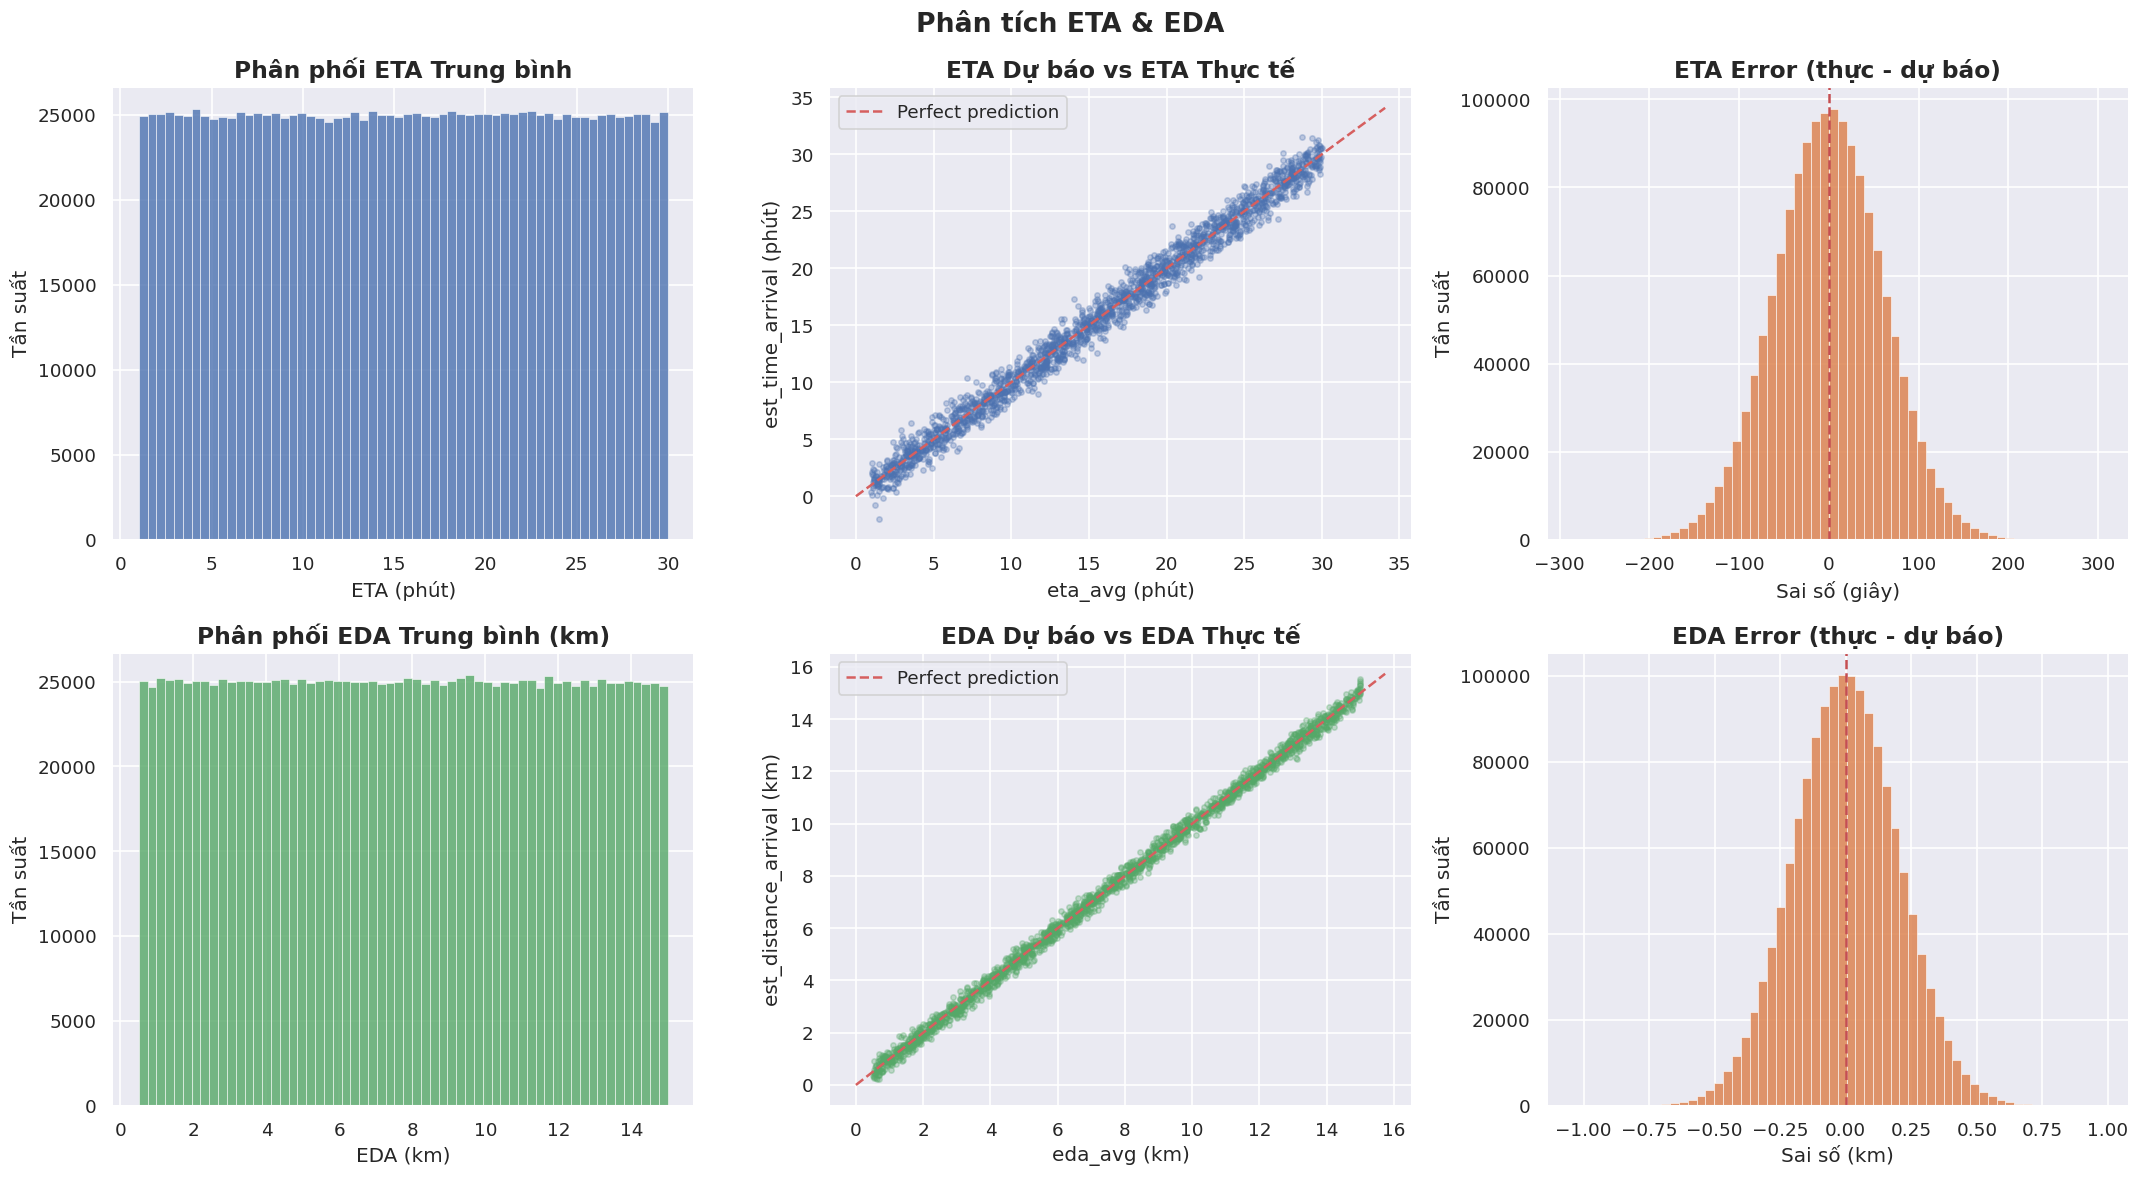

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- ETA ---
# 5a. Phân phối eta_avg
ax = axes[0][0]
ax.hist(df['eta_avg'] / 60, bins=60, color=COLOR_PRIMARY, alpha=0.8, edgecolor='white', linewidth=0.4)
ax.set_title('Phân phối ETA Trung bình', fontweight='bold')
ax.set_xlabel('ETA (phút)')
ax.set_ylabel('Tần suất')

# 5b. ETA avg vs ETA thực tế (est_time_arrival)
ax2 = axes[0][1]
sample = df.sample(2000, random_state=42)
ax2.scatter(sample['eta_avg'] / 60, sample['est_time_arrival'] / 60,
            alpha=0.3, s=10, color=COLOR_PRIMARY)
lim_max = max(df['eta_avg'].max(), df['est_time_arrival'].max()) / 60
ax2.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_title('ETA Dự báo vs ETA Thực tế', fontweight='bold')
ax2.set_xlabel('eta_avg (phút)')
ax2.set_ylabel('est_time_arrival (phút)')
ax2.legend()

# 5c. ETA error distribution
ax3 = axes[0][2]
eta_error = df['est_time_arrival'] - df['eta_avg']
ax3.hist(eta_error, bins=60, color=COLOR_ACCENT, alpha=0.85, edgecolor='white', linewidth=0.4)
ax3.axvline(0, color=COLOR_DANGER, linestyle='--', linewidth=1.5)
ax3.set_title('ETA Error (thực - dự báo)', fontweight='bold')
ax3.set_xlabel('Sai số (giây)')
ax3.set_ylabel('Tần suất')

# --- EDA ---
# 5d. Phân phối eda_avg
ax4 = axes[1][0]
ax4.hist(df['eda_avg'], bins=60, color=COLOR_SUCCESS, alpha=0.8, edgecolor='white', linewidth=0.4)
ax4.set_title('Phân phối EDA Trung bình (km)', fontweight='bold')
ax4.set_xlabel('EDA (km)')
ax4.set_ylabel('Tần suất')

# 5e. EDA avg vs EDA thực tế
ax5 = axes[1][1]
ax5.scatter(sample['eda_avg'], sample['est_distance_arrival'],
            alpha=0.3, s=10, color=COLOR_SUCCESS)
lim_max2 = max(df['eda_avg'].max(), df['est_distance_arrival'].max())
ax5.plot([0, lim_max2], [0, lim_max2], 'r--', linewidth=1.5, label='Perfect prediction')
ax5.set_title('EDA Dự báo vs EDA Thực tế', fontweight='bold')
ax5.set_xlabel('eda_avg (km)')
ax5.set_ylabel('est_distance_arrival (km)')
ax5.legend()

# 5f. EDA error
ax6 = axes[1][2]
eda_error = df['est_distance_arrival'] - df['eda_avg']
ax6.hist(eda_error, bins=60, color=COLOR_ACCENT, alpha=0.85, edgecolor='white', linewidth=0.4)
ax6.axvline(0, color=COLOR_DANGER, linestyle='--', linewidth=1.5)
ax6.set_title('EDA Error (thực - dự báo)', fontweight='bold')
ax6.set_xlabel('Sai số (km)')
ax6.set_ylabel('Tần suất')

plt.suptitle('Phân tích ETA & EDA', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Phân tích Giá (total_fee / total_pay)

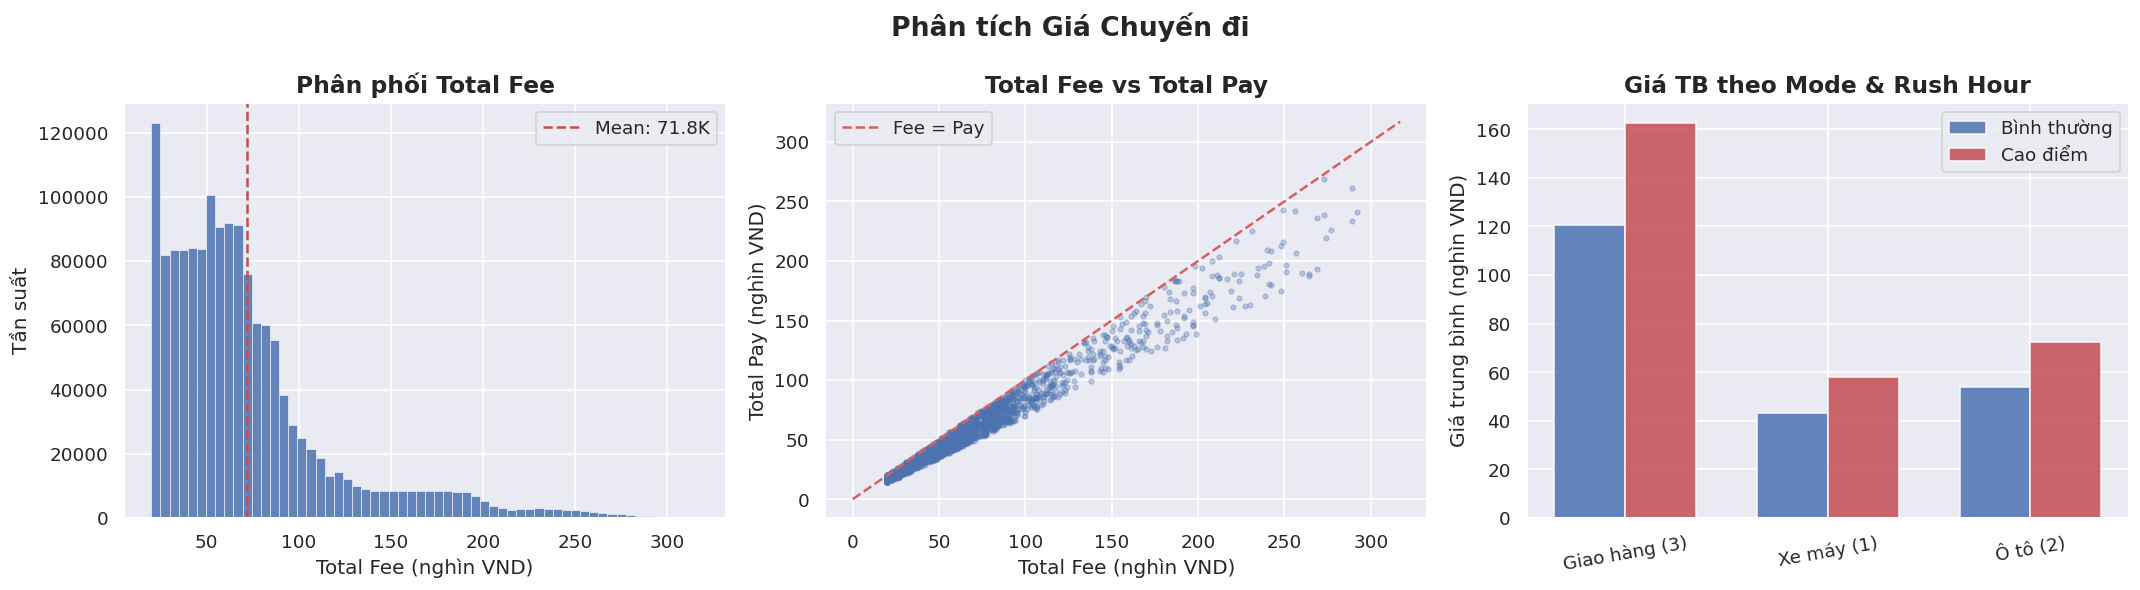

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 6a. Phân phối total_fee
ax = axes[0]
ax.hist(df['total_fee'] / 1000, bins=60, color=COLOR_PRIMARY, alpha=0.85, edgecolor='white', linewidth=0.4)
ax.set_title('Phân phối Total Fee', fontweight='bold')
ax.set_xlabel('Total Fee (nghìn VND)')
ax.set_ylabel('Tần suất')
ax.axvline(df['total_fee'].mean() / 1000, color=COLOR_DANGER, linestyle='--',
           linewidth=1.5, label=f"Mean: {df['total_fee'].mean()/1000:.1f}K")
ax.legend()

# 6b. total_fee vs total_pay
ax2 = axes[1]
ax2.scatter(sample['total_fee'] / 1000, sample['total_pay'] / 1000,
            alpha=0.3, s=8, color=COLOR_PRIMARY)
lim = max(df['total_fee'].max(), df['total_pay'].max()) / 1000
ax2.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Fee = Pay')
ax2.set_title('Total Fee vs Total Pay', fontweight='bold')
ax2.set_xlabel('Total Fee (nghìn VND)')
ax2.set_ylabel('Total Pay (nghìn VND)')
ax2.legend()

# 6c. Giá trung bình theo travel_mode + rush_hour
ax3 = axes[2]
fee_by_mode_rush = df.groupby(['travel_mode_label', 'rush_hour'])['total_fee'].mean().unstack()
fee_by_mode_rush.columns = ['Bình thường', 'Cao điểm']
fee_by_mode_rush = fee_by_mode_rush / 1000
x = np.arange(len(fee_by_mode_rush))
width = 0.35
ax3.bar(x - width/2, fee_by_mode_rush['Bình thường'], width, label='Bình thường', color=COLOR_PRIMARY, alpha=0.85)
ax3.bar(x + width/2, fee_by_mode_rush['Cao điểm'], width, label='Cao điểm', color=COLOR_DANGER, alpha=0.85)
ax3.set_title('Giá TB theo Mode & Rush Hour', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Giá trung bình (nghìn VND)')
ax3.set_xticks(x)
ax3.set_xticklabels(fee_by_mode_rush.index, rotation=10)
ax3.legend()

plt.suptitle('Phân tích Giá Chuyến đi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Tỉ lệ hoàn thành (is_completed)

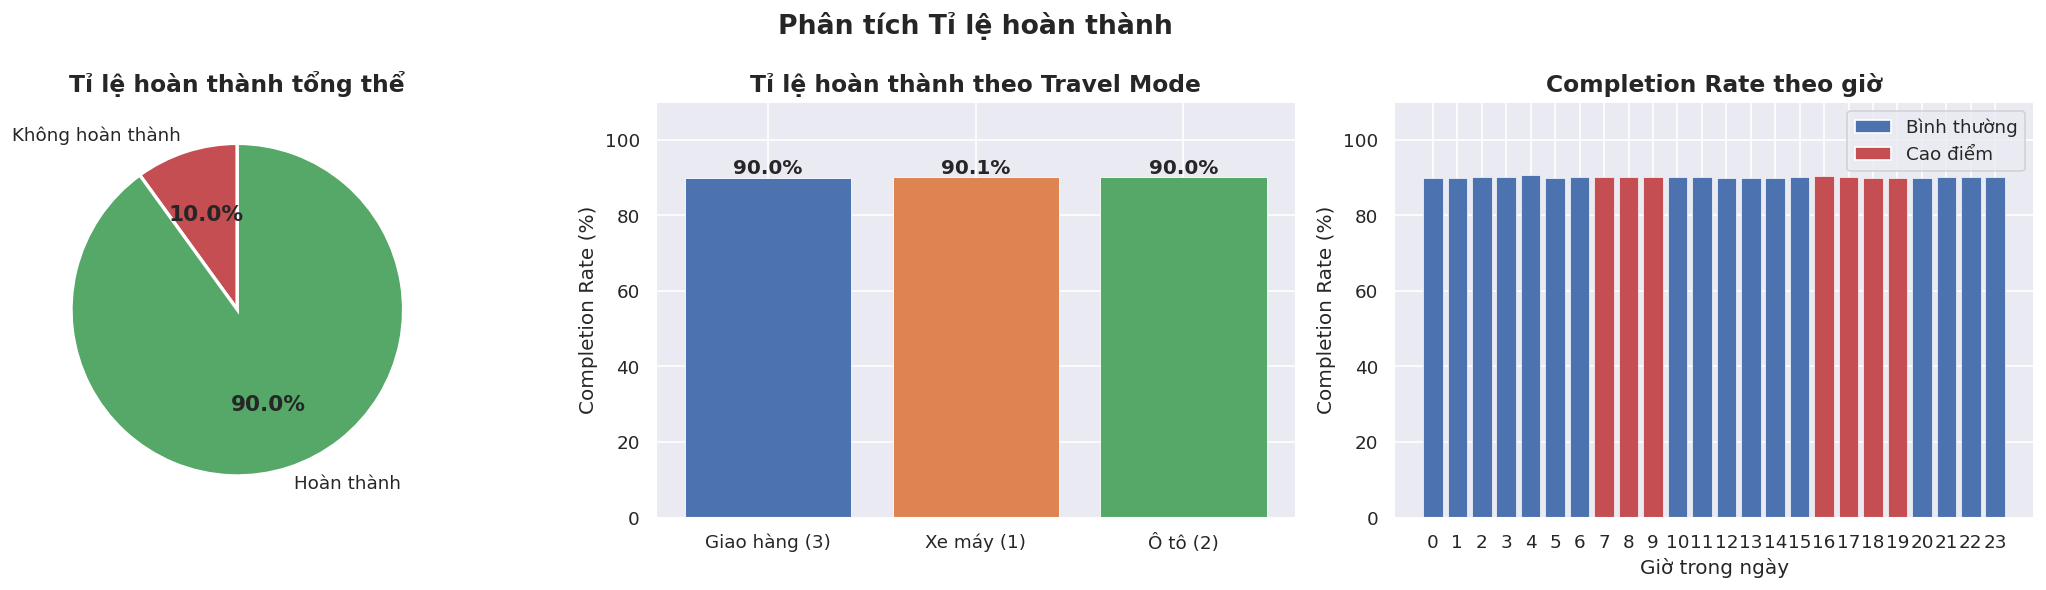

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 7a. Tỉ lệ hoàn thành tổng thể
ax = axes[0]
comp_counts = df['is_completed'].value_counts().sort_index()
labels = ['Không hoàn thành', 'Hoàn thành']
colors_comp = [COLOR_DANGER, COLOR_SUCCESS]
wedges, texts, autotexts = ax.pie(
    comp_counts.values, labels=labels, colors=colors_comp,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax.set_title('Tỉ lệ hoàn thành tổng thể', fontweight='bold')

# 7b. Completion rate theo travel mode
ax2 = axes[1]
comp_by_mode = df.groupby('travel_mode_label')['is_completed'].mean() * 100
bars = ax2.bar(comp_by_mode.index, comp_by_mode.values,
               color=PALETTE_MODE, edgecolor='white', linewidth=0.5)
ax2.set_title('Tỉ lệ hoàn thành theo Travel Mode', fontweight='bold')
ax2.set_ylabel('Completion Rate (%)')
ax2.set_ylim(0, 110)
for bar, val in zip(bars, comp_by_mode.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
             ha='center', fontweight='bold')

# 7c. Completion rate theo giờ
ax3 = axes[2]
comp_by_hour = df.groupby('hour_of_day')['is_completed'].mean() * 100
rush_hours = list(range(7, 10)) + list(range(16, 20))
bar_colors = [COLOR_DANGER if h in rush_hours else COLOR_PRIMARY for h in comp_by_hour.index]
ax3.bar(comp_by_hour.index, comp_by_hour.values, color=bar_colors, edgecolor='white', linewidth=0.4)
ax3.set_title('Completion Rate theo giờ', fontweight='bold')
ax3.set_xlabel('Giờ trong ngày')
ax3.set_ylabel('Completion Rate (%)')
ax3.set_xticks(range(24))
ax3.set_ylim(0, 110)
legend_elements = [Patch(facecolor=COLOR_PRIMARY, label='Bình thường'),
                   Patch(facecolor=COLOR_DANGER, label='Cao điểm')]
ax3.legend(handles=legend_elements)

plt.suptitle('Phân tích Tỉ lệ hoàn thành', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

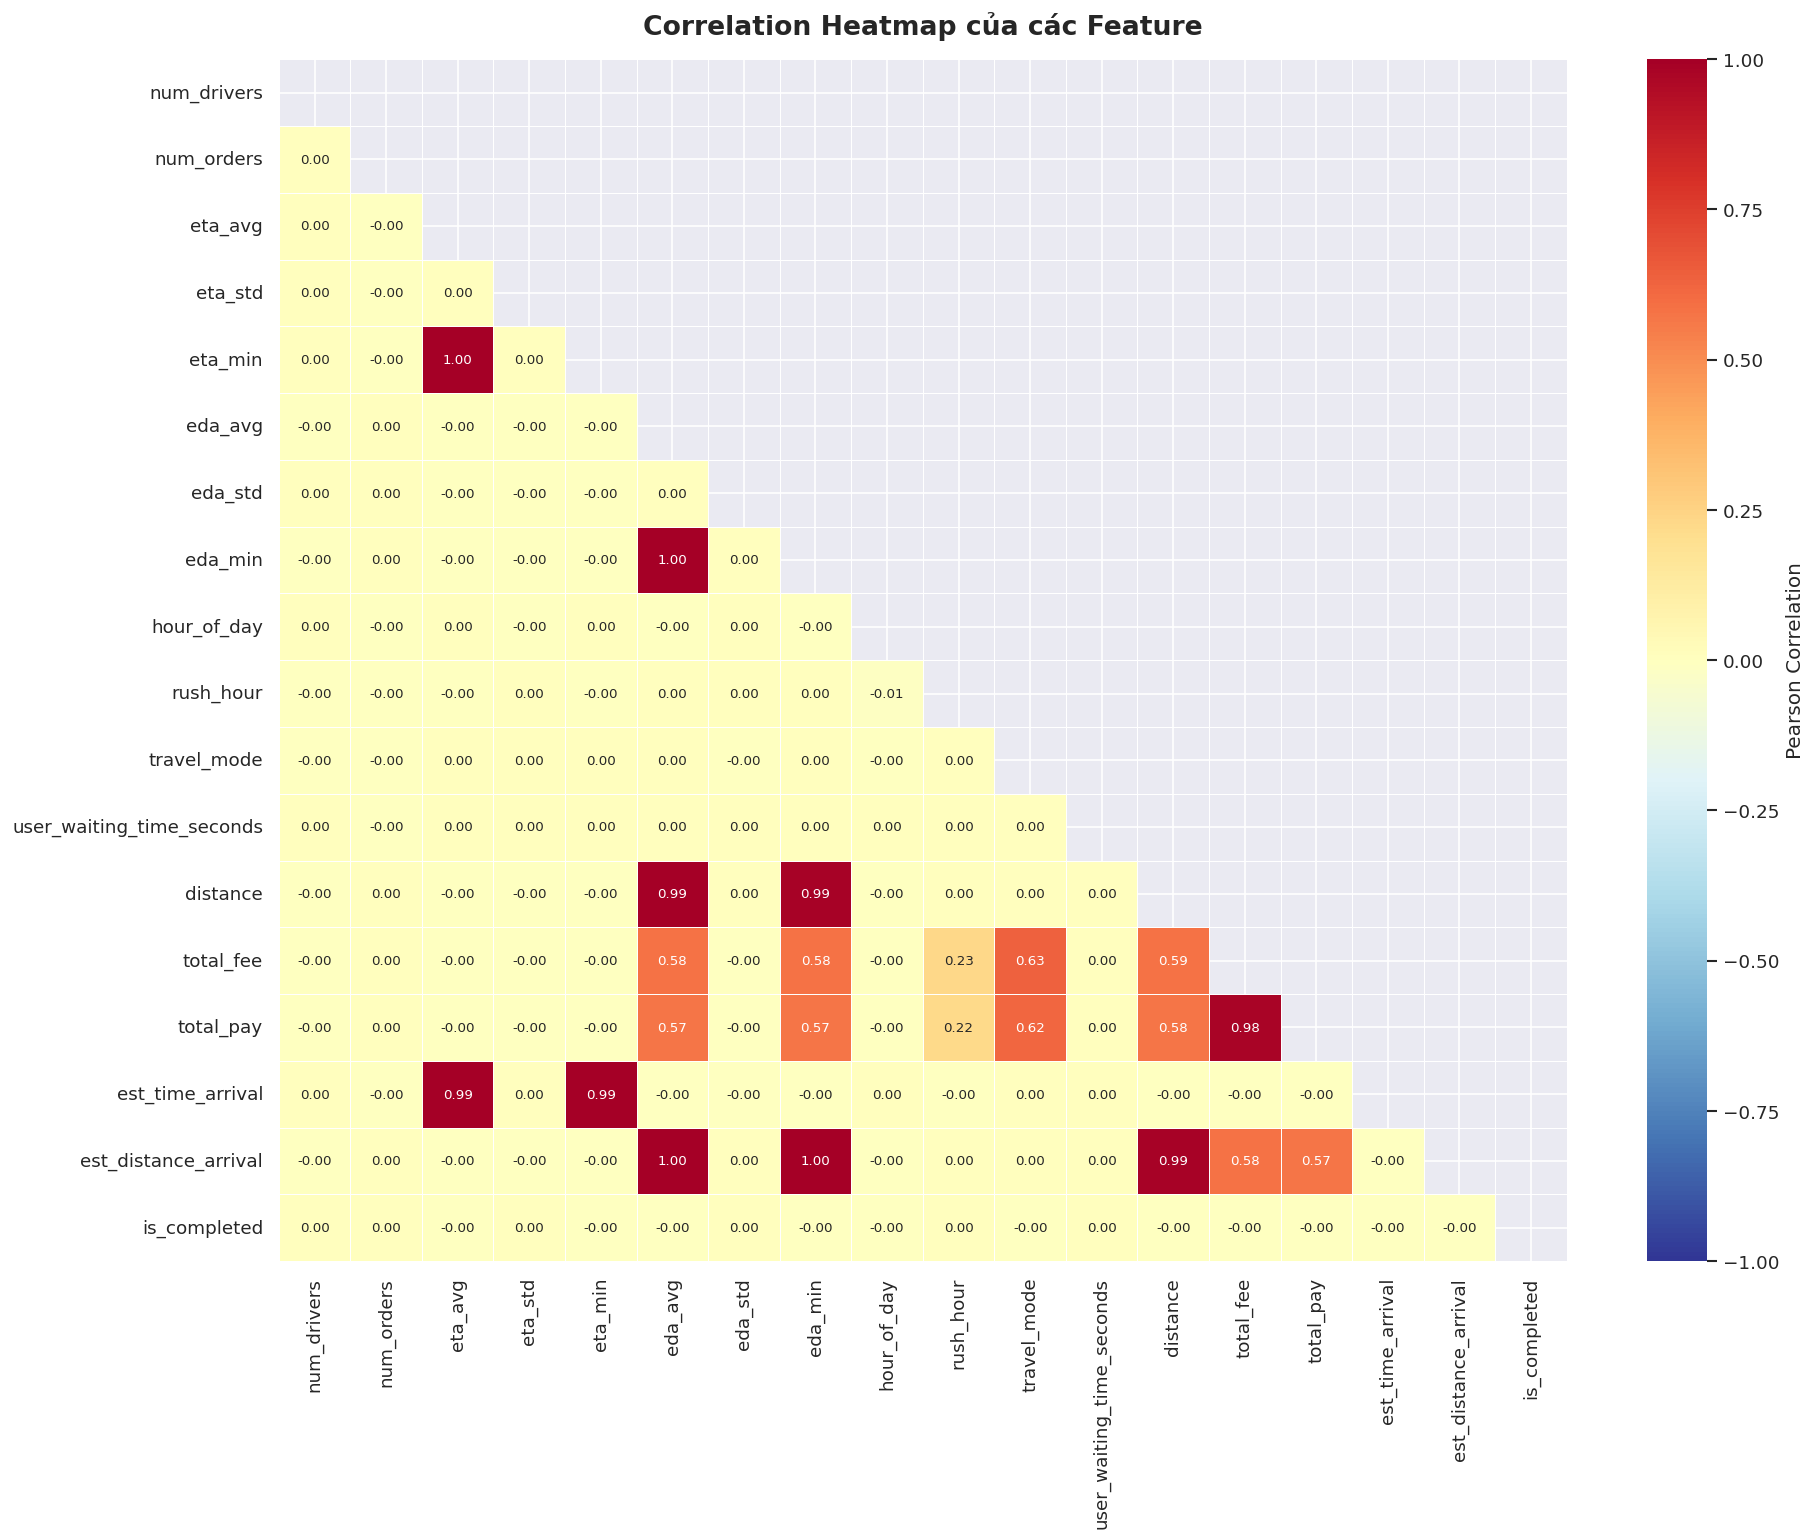

In [12]:
corr_cols = [
    'num_drivers', 'num_orders',
    'eta_avg', 'eta_std', 'eta_min',
    'eda_avg', 'eda_std', 'eda_min',
    'hour_of_day', 'rush_hour',
    'travel_mode', 'user_waiting_time_seconds',
    'distance', 'total_fee', 'total_pay',
    'est_time_arrival', 'est_distance_arrival',
    'is_completed',
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Pearson Correlation'}
)

ax.set_title('Correlation Heatmap của các Feature', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

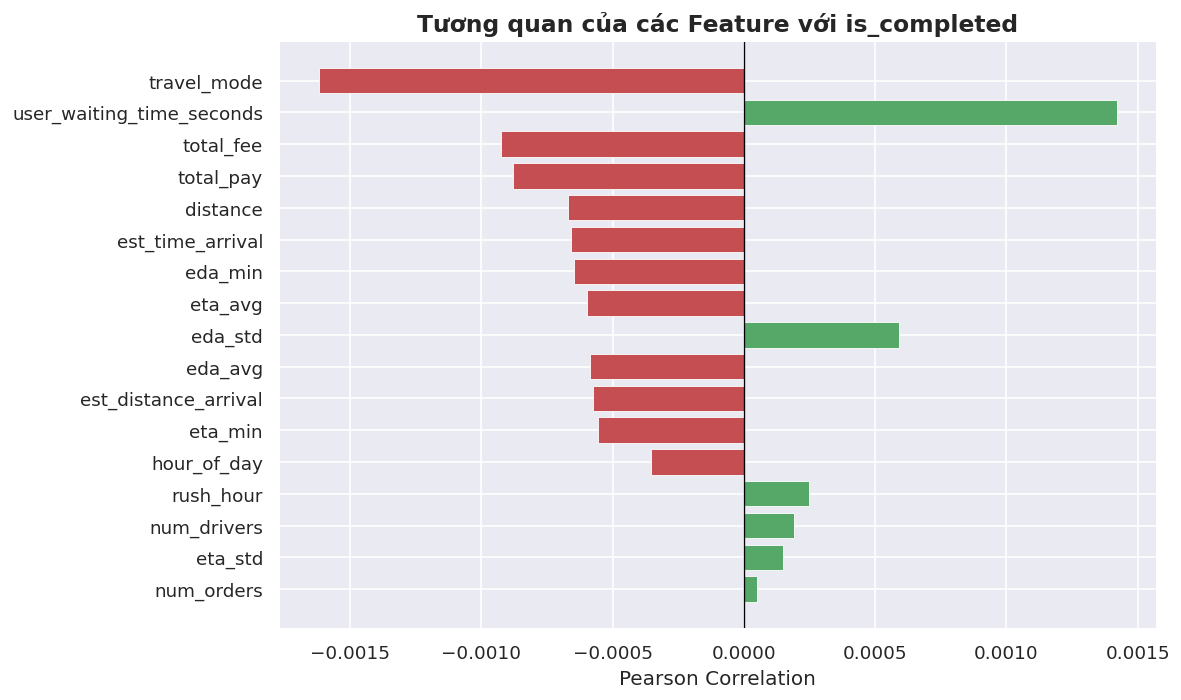

In [13]:
# Top correlations với is_completed
target_corr = corr_matrix['is_completed'].drop('is_completed').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [COLOR_SUCCESS if v > 0 else COLOR_DANGER for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Tương quan của các Feature với is_completed', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Phân tích số lượng tài xế & đơn hàng

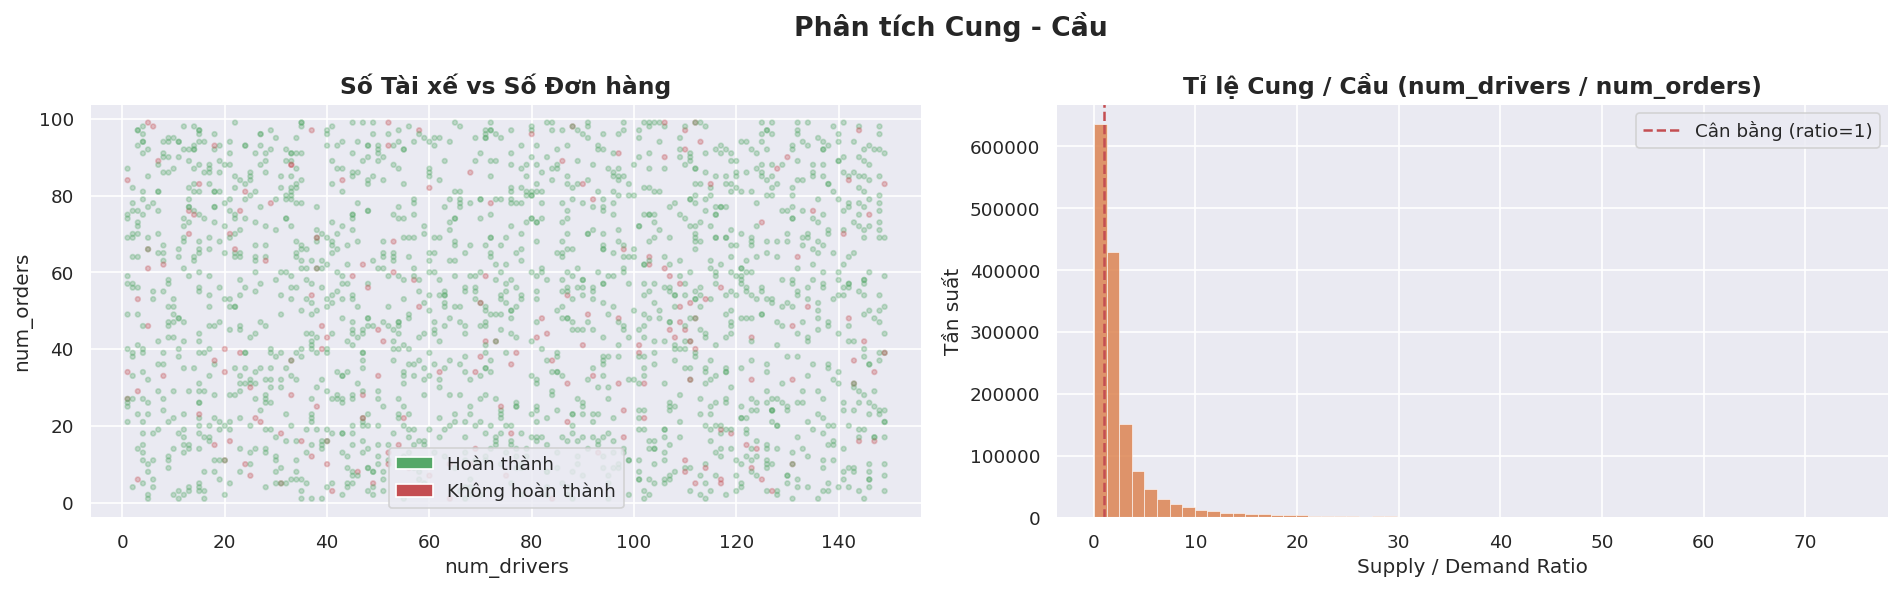

Supply > Demand: 65.9%
Supply < Demand: 33.5%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: num_drivers vs num_orders, tô màu theo is_completed
ax = axes[0]
colors_scatter = [COLOR_SUCCESS if c == 1 else COLOR_DANGER for c in sample['is_completed']]
ax.scatter(sample['num_drivers'], sample['num_orders'],
           c=colors_scatter, alpha=0.3, s=8)
ax.set_title('Số Tài xế vs Số Đơn hàng', fontweight='bold')
ax.set_xlabel('num_drivers')
ax.set_ylabel('num_orders')
legend_elements = [Patch(facecolor=COLOR_SUCCESS, label='Hoàn thành'),
                   Patch(facecolor=COLOR_DANGER, label='Không hoàn thành')]
ax.legend(handles=legend_elements)

# Supply/Demand ratio
ax2 = axes[1]
df['supply_demand_ratio'] = df['num_drivers'] / (df['num_orders'] + 1)
ax2.hist(df['supply_demand_ratio'], bins=60, color=COLOR_ACCENT, alpha=0.85,
         edgecolor='white', linewidth=0.4)
ax2.axvline(1.0, color=COLOR_DANGER, linestyle='--', linewidth=1.5, label='Cân bằng (ratio=1)')
ax2.set_title('Tỉ lệ Cung / Cầu (num_drivers / num_orders)', fontweight='bold')
ax2.set_xlabel('Supply / Demand Ratio')
ax2.set_ylabel('Tần suất')
ax2.legend()

plt.suptitle('Phân tích Cung - Cầu', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Supply > Demand: {(df['supply_demand_ratio'] > 1).mean()*100:.1f}%")
print(f"Supply < Demand: {(df['supply_demand_ratio'] < 1).mean()*100:.1f}%")

Tổng số batch   : 856,194
Batch size TB   : 1.75 đơn/batch
Batch size Max  : 10 đơn
Batch size Min  : 1 đơn
num_orders
1     429601
2     269044
3     111656
4      34864
5       8768
6       1844
7        362
8         47
9          7
10         1
Name: count, dtype: int64


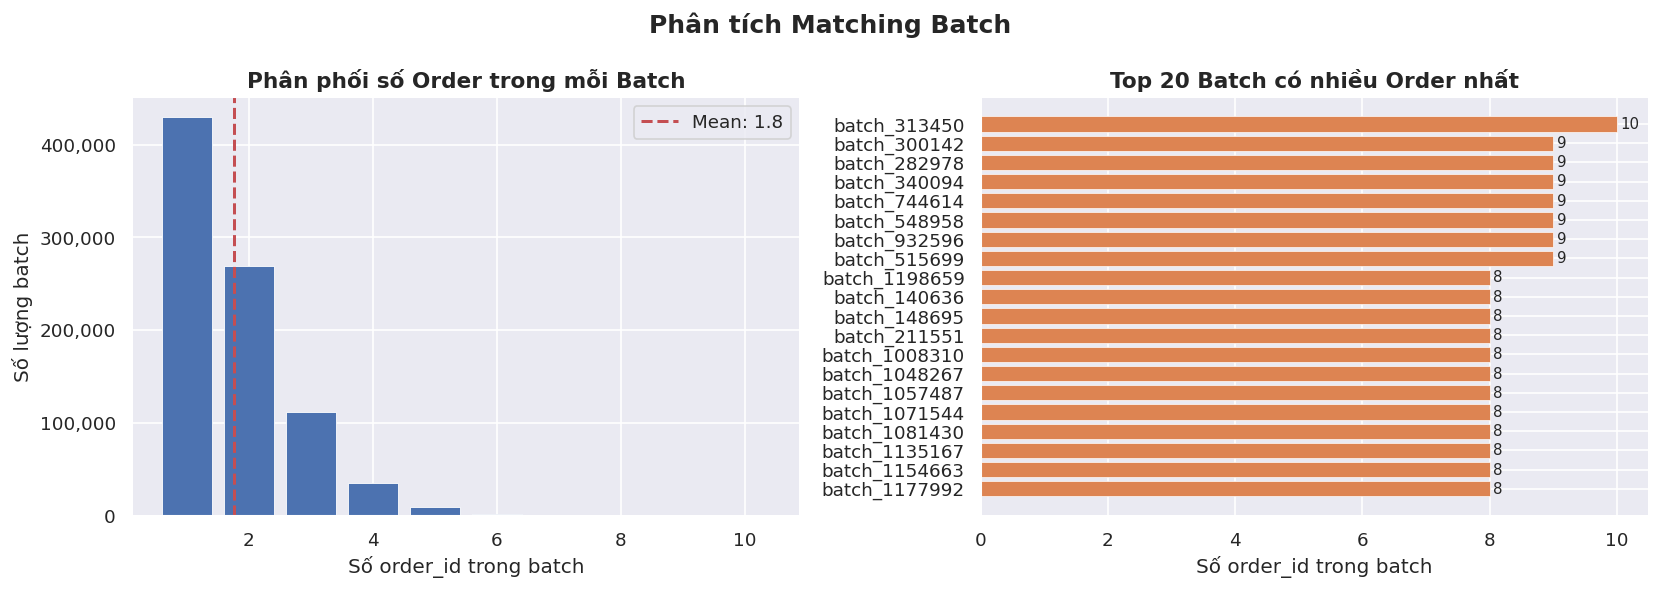

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Load data
df = pd.read_csv("../data/raw/synthetic_ride_data.csv")

# Tính số order_id trong mỗi batch
batch_size = df.groupby("matching_batch_id")["order_id"].count().reset_index()
batch_size.columns = ["matching_batch_id", "num_orders"]

print(f"Tổng số batch   : {batch_size.shape[0]:,}")
print(f"Batch size TB   : {batch_size['num_orders'].mean():.2f} đơn/batch")
print(f"Batch size Max  : {batch_size['num_orders'].max()} đơn")
print(f"Batch size Min  : {batch_size['num_orders'].min()} đơn")
print(batch_size['num_orders'].value_counts().sort_index().head(10))

# ── Visualize ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân phối số order trong mỗi batch
ax = axes[0]
counts = batch_size["num_orders"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.axvline(batch_size["num_orders"].mean(), color="#C44E52", linestyle="--",
           linewidth=1.8, label=f"Mean: {batch_size['num_orders'].mean():.1f}")
ax.set_title("Phân phối số Order trong mỗi Batch", fontweight="bold", fontsize=13)
ax.set_xlabel("Số order_id trong batch")
ax.set_ylabel("Số lượng batch")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()

# 2. Top 20 batch có nhiều order nhất
ax2 = axes[1]
top20 = batch_size.nlargest(20, "num_orders").sort_values("num_orders")
ax2.barh(top20["matching_batch_id"], top20["num_orders"],
         color="#DD8452", edgecolor="white", linewidth=0.4)
for i, (_, row) in enumerate(top20.iterrows()):
    ax2.text(row["num_orders"] + 0.05, i,
             str(int(row["num_orders"])), va="center", fontsize=9)
ax2.set_title("Top 20 Batch có nhiều Order nhất", fontweight="bold", fontsize=13)
ax2.set_xlabel("Số order_id trong batch")

plt.suptitle("Phân tích Matching Batch", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
